In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv("/Users/prasanthi/Downloads/train.csv")

In [3]:
data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [4]:
data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [5]:
data.tail(6)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1994,858,0,2.2,0,1,0,50,0.1,84,1,...,528,1416,3978,17,16,3,1,1,0,3
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [6]:
data.shape

(2000, 21)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [8]:
data.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [9]:
data['price_range']=data['price_range'].map({0:0,1:0,2:1,3:1})
data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,0
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,1
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,1
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,1
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,1
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,1
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [10]:
data1=data.drop(['px_width','clock_speed','px_height','sc_h','sc_w','pc','m_dep','mobile_wt'],axis=1)

In [11]:
data1

,battery_power,blue,dual_sim,fc,four_g,int_memory,n_cores,ram,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,0,1,0,7,2,2549,19,0,0,1,0
1,1021,1,1,0,1,53,3,2631,7,1,1,0,1
2,563,1,1,2,1,41,5,2603,9,1,1,0,1
3,615,1,0,0,0,10,6,2769,11,1,0,0,1
4,1821,1,0,13,1,44,2,1411,15,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,1,0,1,2,6,668,19,1,1,0,0
1996,1965,1,1,0,0,39,4,2032,16,1,1,1,1
1997,1911,0,1,1,1,36,8,3057,5,1,1,0,1
1998,1512,0,0,4,1,46,5,869,19,1,1,1,0


In [12]:
data9=data1.groupby(['wifi']).count()
data9

,battery_power,blue,dual_sim,fc,four_g,int_memory,n_cores,ram,talk_time,three_g,touch_screen,price_range
wifi,,,,,,,,,,,,
0,986,986,986,986,986,986,986,986,986,986,986,986
1,1014,1014,1014,1014,1014,1014,1014,1014,1014,1014,1014,1014


In [13]:
data0=data1.groupby(['three_g']).count()
data0

,battery_power,blue,dual_sim,fc,four_g,int_memory,n_cores,ram,talk_time,touch_screen,wifi,price_range
three_g,,,,,,,,,,,,
0,477,477,477,477,477,477,477,477,477,477,477,477
1,1523,1523,1523,1523,1523,1523,1523,1523,1523,1523,1523,1523


talk_time
7     124
4     123
16    116
15    115
19    113
6     111
10    105
8     104
11    103
20    102
14    101
13    100
18    100
9     100
2      99
12     99
17     98
3      94
5      93
Name: count, dtype: int64


<Axes: xlabel='talk_time', ylabel='count'>

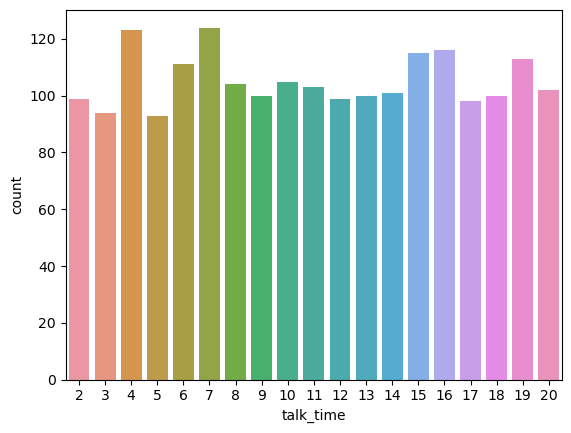

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
data2=data['talk_time'].value_counts()
print(data2)
sns.countplot(x="talk_time",data=data)

dual_sim
1    1019
0     981
Name: count, dtype: int64


<Axes: xlabel='dual_sim', ylabel='count'>

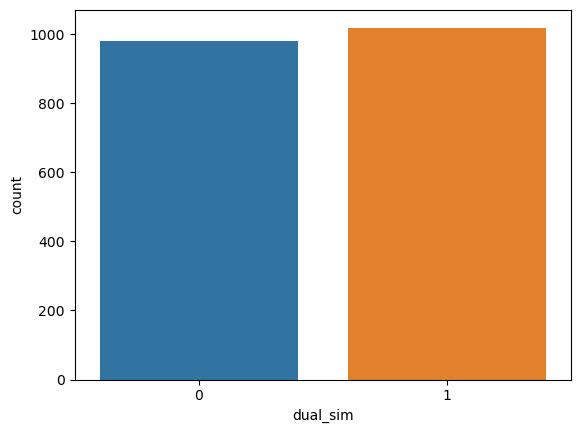

In [15]:
data3=data['dual_sim'].value_counts()
print(data3)
sns.countplot(x="dual_sim",data=data)

In [16]:
cor=data1.corr()
cor

,battery_power,blue,dual_sim,fc,four_g,int_memory,n_cores,ram,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,-0.041847,0.033334,0.015665,-0.004004,-0.029727,-0.000653,0.052510,0.011522,-0.010516,-0.008343,0.149402
blue,0.011252,1.000000,0.035198,0.003593,0.013443,0.041177,0.036161,0.026351,0.013934,-0.030236,0.010061,-0.021863,0.014001
dual_sim,-0.041847,0.035198,1.000000,-0.029123,0.003187,-0.015679,-0.024658,0.041072,-0.039404,-0.014008,-0.017117,0.022740,0.009002
fc,0.033334,0.003593,-0.029123,1.000000,-0.016560,-0.029133,-0.013356,0.015099,-0.006829,0.001793,-0.014828,0.020085,0.022464
four_g,0.015665,0.013443,0.003187,-0.016560,1.000000,0.008690,-0.029706,0.007313,-0.046628,0.584246,0.016758,-0.017620,0.001001
int_memory,-0.004004,0.041177,-0.015679,-0.029133,0.008690,1.000000,-0.028310,0.032813,-0.002790,-0.009366,-0.026999,0.006993,0.022132
n_cores,-0.029727,0.036161,-0.024658,-0.013356,-0.029706,-0.028310,1.000000,0.004868,0.013148,-0.014733,0.023774,-0.009964,0.031260
ram,-0.000653,0.026351,0.041072,0.015099,0.007313,0.032813,0.004868,1.000000,0.010820,0.015795,-0.030455,0.022669,0.822354
talk_time,0.052510,0.013934,-0.039404,-0.006829,-0.046628,-0.002790,0.013148,0.010820,1.000000,-0.042688,0.017196,-0.029504,0.004394
three_g,0.011522,-0.030236,-0.014008,0.001793,0.584246,-0.009366,-0.014733,0.015795,-0.042688,1.000000,0.013917,0.004316,0.024638


<Axes: >

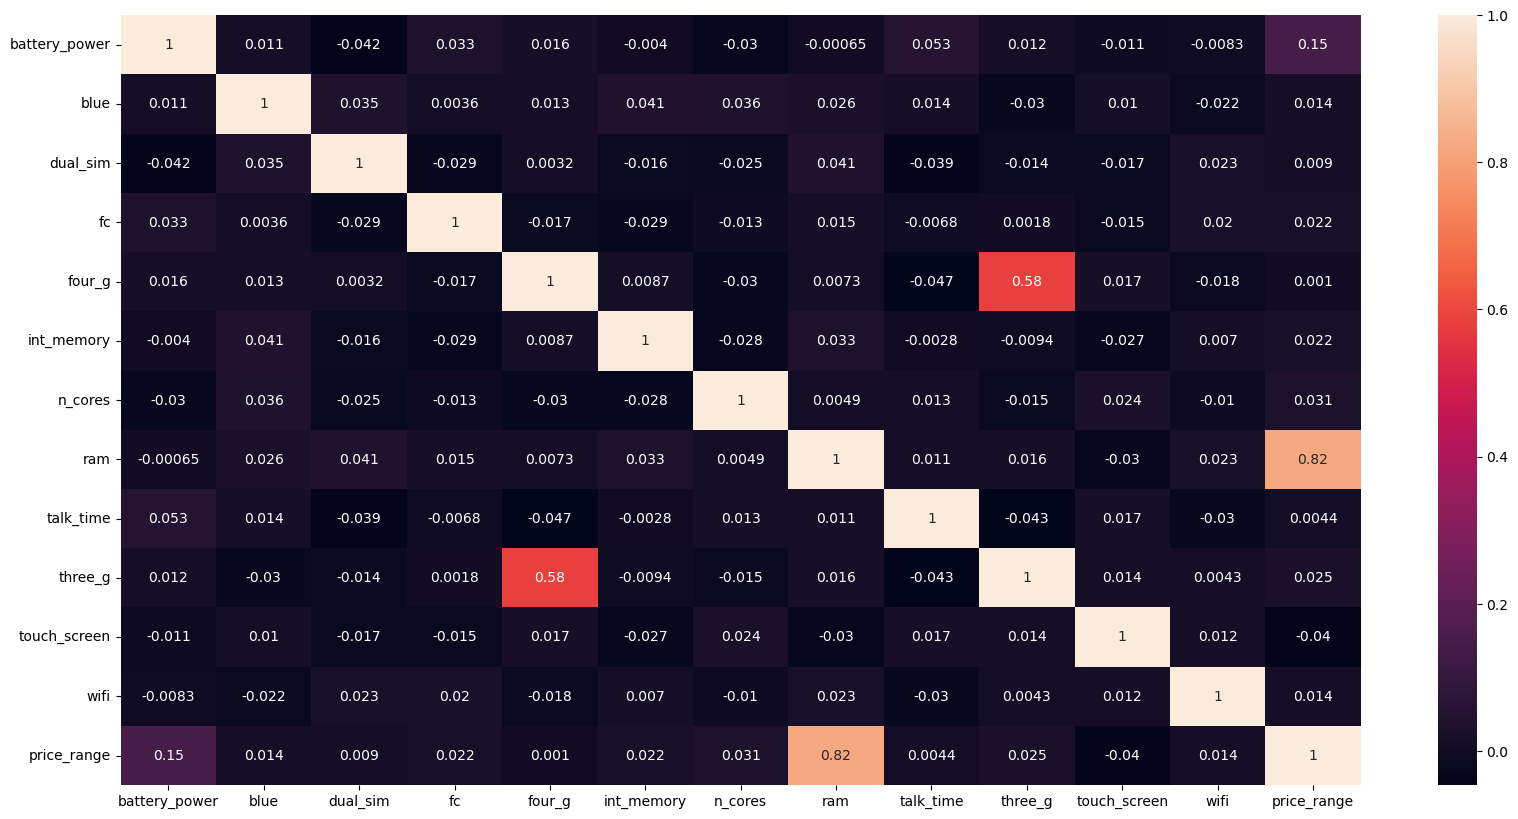

In [17]:
import seaborn as sns
plt.figure(figsize=(20,10))
cor=data1.corr()
sns.heatmap(cor,annot=True)

In [18]:
y=data1['price_range']
x=data1.drop('price_range',axis=1)

In [19]:
y

0       0
1       1
2       1
3       1
4       0
       ..
1995    0
1996    1
1997    1
1998    0
1999    1
Name: price_range, Length: 2000, dtype: int64

In [20]:
x

,battery_power,blue,dual_sim,fc,four_g,int_memory,n_cores,ram,talk_time,three_g,touch_screen,wifi
0,842,0,0,1,0,7,2,2549,19,0,0,1
1,1021,1,1,0,1,53,3,2631,7,1,1,0
2,563,1,1,2,1,41,5,2603,9,1,1,0
3,615,1,0,0,0,10,6,2769,11,1,0,0
4,1821,1,0,13,1,44,2,1411,15,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,1,0,1,2,6,668,19,1,1,0
1996,1965,1,1,0,0,39,4,2032,16,1,1,1
1997,1911,0,1,1,1,36,8,3057,5,1,1,0
1998,1512,0,0,4,1,46,5,869,19,1,1,1


In [21]:
 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33,random_state=49) 



In [22]:
x_train.shape

(1340, 12)

In [23]:
x_test.head(6)

,battery_power,blue,dual_sim,fc,four_g,int_memory,n_cores,ram,talk_time,three_g,touch_screen,wifi
1911,1259,0,1,0,0,13,2,340,4,1,0,1
181,1165,1,0,11,0,41,6,764,15,1,0,0
694,1310,0,0,0,0,33,1,1301,19,0,0,1
1810,594,1,0,1,0,27,5,708,17,0,1,1
667,600,0,0,1,0,48,3,3393,8,1,0,0
344,618,0,0,2,0,6,1,1051,15,0,0,1


In [24]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
classifier.fit(x_train,y_train)

LogisticRegression()

In [25]:
y_pred=classifier.predict(x_test)
y_pred

array([0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,

In [26]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[281,  36],
       [ 42, 301]])

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8818181818181818

In [28]:
Results= pd.DataFrame(columns=['actual','predicted'])
Results['actual']=y_test
Results['predicted']=y_pred
Results=Results.reset_index()
Results['ID']=Results.index
Results.head(10)

,index,actual,predicted,ID
0,1911,0,0,0
1,181,0,0,1
2,694,0,0,2
3,1810,0,0,3
4,667,1,1,4
5,344,0,0,5
6,273,0,0,6
7,1103,1,1,7
8,21,1,1,8
9,714,1,1,9


[]

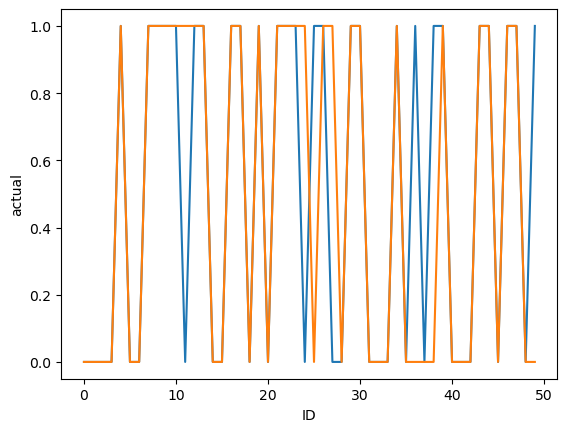

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(x='ID',y='actual',data=Results.head(50))
sns.lineplot(x='ID',y='predicted',data=Results.head(50))
plt.plot()

In [30]:
from sklearn.tree import DecisionTreeClassifier

In [31]:
cls=DecisionTreeClassifier()

In [32]:
cls.fit(x_train,y_train)

DecisionTreeClassifier()

In [33]:
y_pred=cls.predict(x_test)
y_pred

array([0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,

In [34]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)  

0.906060606060606

In [35]:
from sklearn.model_selection import GridSearchCV #GridSearchCV is for parameter tuning
from sklearn.ensemble import RandomForestClassifier
cls=RandomForestClassifier()
n_estimators=[25,50,75,100,125,150,175,200] #number of decision trees in the forest, default = 100
criterion=['gini','entropy'] #criteria for choosing nodes default = 'gini'
max_depth=[3,5,10] #maximum number of nodes in a tree default = None (it will go till all possible nodes)
parameters={'n_estimators': n_estimators,'criterion':criterion,'max_depth':max_depth}  
RFC_cls = GridSearchCV(cls, parameters)
RFC_cls.fit(x_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10],
                         'n_estimators': [25, 50, 75, 100, 125, 150, 175, 200]})

In [36]:
RFC_cls.best_params_

{'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 25}

In [37]:
cls=RandomForestClassifier(n_estimators=75,criterion='entropy',max_depth=10)

In [38]:
cls.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', max_depth=10, n_estimators=75)

In [39]:
y_pred=cls.predict(x_test)
y_pred

array([0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,

In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)  

0.9227272727272727